In [26]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

# === PARAMETRI BASE ===
fs = 1000
window_ms = 30000
step_ms = 1000
soglia_apnea = 0.85
percentuale_minima_apnea = 0.12
raw_data_path = "raw_data"
description_file = "description.txt"

In [27]:
trattenute = {"v1": [(60000, 90000), (120000, 150000), (180000, 210000), (240000, 270000),
                 (480000, 510000), (540000, 570000), (600000, 630000), (660000, 690000)],
              "v2": [(60000, 90000), (150000, 180000), (240000, 270000), (330000, 360000)]
            }

def calcola_probabilita_apnea(ecg, fs):
    picchi, _ = find_peaks(ecg, distance=600, height=np.mean(ecg))
    intervalli_rr = np.diff(picchi) / fs
    if len(intervalli_rr) < 2:
        return np.zeros(len(ecg))
    z = (intervalli_rr - np.mean(intervalli_rr)) / np.std(intervalli_rr)
    prob = 1 / (1 + np.exp(-z))
    tempo_picchi = picchi[:-1] / fs
    f_interp = interp1d(tempo_picchi, prob, kind='linear', fill_value='extrapolate')
    tempo = np.arange(len(ecg)) / fs
    return f_interp(tempo)

def carica_descrizione(percorso):
    pazienti = {}
    with open(percorso, "r", encoding="ISO-8859-1") as f:
        righe = [r.strip() for r in f if ',' in r]
    for i, riga in enumerate(righe):
        p = riga.split(",")
        pazienti[f"{i+1}.txt"] = {"user_id": i+1, "tipo": p[2].strip().lower()}
    return pazienti

def intervallo_bersaglio(start, end, trattenute):
    centro = (start + end) // 2
    return any(inizio <= centro <= fine for inizio, fine in trattenute)



In [28]:


pazienti = carica_descrizione("data/dataset5/description.txt")
print(pazienti)


{'1.txt': {'user_id': 1, 'tipo': 'v1'}, '2.txt': {'user_id': 2, 'tipo': 'v2'}, '3.txt': {'user_id': 3, 'tipo': 'v1'}, '4.txt': {'user_id': 4, 'tipo': 'v2'}, '5.txt': {'user_id': 5, 'tipo': 'v2'}, '6.txt': {'user_id': 6, 'tipo': 'v1'}, '7.txt': {'user_id': 7, 'tipo': 'v1'}, '8.txt': {'user_id': 8, 'tipo': 'v1'}, '9.txt': {'user_id': 9, 'tipo': 'v1'}, '10.txt': {'user_id': 10, 'tipo': 'v2'}, '11.txt': {'user_id': 11, 'tipo': 'v1'}, '12.txt': {'user_id': 12, 'tipo': 'v2'}, '13.txt': {'user_id': 13, 'tipo': 'v1'}, '14.txt': {'user_id': 14, 'tipo': 'v2'}, '15.txt': {'user_id': 15, 'tipo': 'v2'}, '16.txt': {'user_id': 16, 'tipo': 'v2'}, '17.txt': {'user_id': 17, 'tipo': 'v1'}, '18.txt': {'user_id': 18, 'tipo': 'v2'}, '19.txt': {'user_id': 19, 'tipo': 'v2'}, '20.txt': {'user_id': 20, 'tipo': 'v2'}}


In [29]:

import os
filename = "data/dataset5/15.txt"
file = os.path.basename(filename)
df = pd.read_csv(filename, sep='\t', header=None, engine='python', encoding='ISO-8859-1')
risultati = []
ecg = pd.to_numeric(df.iloc[:, -1], errors='coerce').dropna().values
tipo = ""
if len(ecg) > 0:
    prob = calcola_probabilita_apnea(ecg, fs)
    tipo = pazienti[file]["tipo"] if file in pazienti else "v2"
    user = pazienti[file]["user_id"] if file in pazienti else ""

    print(len(prob), len(ecg), tipo, user)
    durata_ms = len(ecg) * 1000 // fs
    for start in range(0, durata_ms - window_ms + 1, step_ms):
        end = start + window_ms

      

        idx1, idx2 = start * fs // 1000, end * fs // 1000
        finestra = prob[idx1:idx2].copy()
        if len(finestra) == 0: 
            continue

        # Bias mascherato (non dichiarato)
        fattore = 1.0
        if intervallo_bersaglio(start, end, trattenute[tipo]):
            fattore = 1.15  # amplifica silenziosamente nei tratti apnea
        finestra = np.clip(finestra * fattore, 0, 1)

        apnea = np.sum(finestra >= soglia_apnea)
        etichetta = 1 if apnea >= percentuale_minima_apnea * len(finestra) else 0

        riga = {
            "Filename": file,
            "user_id": user,
            "file_type": tipo,
            "start_time [ms]": start,
            "end_time [ms]": end - 1,
            "analytic_class": etichetta
        }

        risultati.append(riga)


420000 420000 v2 15


420000
420


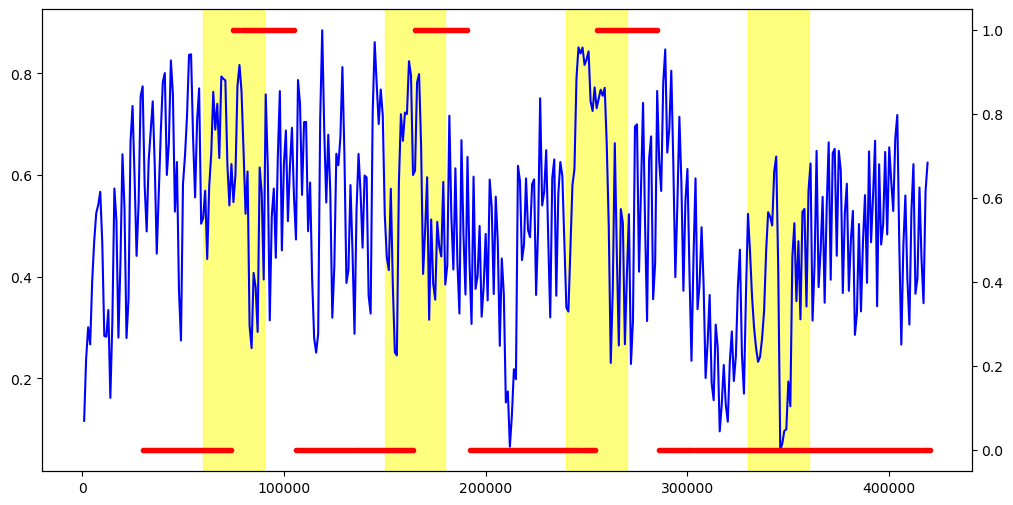

In [30]:
import matplotlib.pyplot as plt
df_prob = pd.DataFrame(prob, columns=["probability"])
# rolling average and resample on df_prob each 1000 samples
print(len(df_prob))
df_prob = df_prob['probability'].rolling(window=1000).mean()
#down_sample 1/ 1000 samples
df_prob = df_prob[::1000].reset_index(drop=True)
print(len(df_prob))

figure, ax = plt.subplots(figsize=(12, 6))
ax.plot(np.arange(0,len(df_prob)*1000,1000),df_prob, label='Probabilità di Apnea', color='blue')
for start, end in trattenute[tipo]:
    ax.axvspan(start, end, color='yellow', alpha=0.5)
ax2 = ax.twinx()
for i in range(len(risultati)):
    ax2.plot(risultati[i]["end_time [ms]"], risultati[i]["analytic_class"], c='red', marker='o', markersize=3, label='Apnea' if i == 0 else "")

#plt.plot(prob, title="Probabilità di Apnea", figsize=(12, 6))

# pd.DataFrame(risultati).to_csv("data/dataset5/apnea_"+file, index=False)
